# Classical vs Quantum GAN Comparison

This notebook implements and compares Classical and Quantum Generative Adversarial Networks (GANs). We'll analyze their performance, training stability, and generation quality.

## 1. Setup and Imports

First, let's import all required libraries and set random seeds for reproducibility.

In [185]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import QGAN implementation
from qgan_implementation import QGAN, QGANConfig

# Missing imports for analysis
import json
from scipy.stats import wasserstein_distance

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. QGAN Configuration and Helper Functions

Let's define configurations for both classical and quantum implementations.

In [186]:
# Configuration for QGAN
qgan_config = QGANConfig(
    num_qubits=6,
    generator_depth=8,
    discriminator_depth=4,
    num_epochs=1000,
    batch_size=32,
    generator_lr=0.001,
    discriminator_lr=0.002,
    backend_type="aer_simulator",
    shots=3000,
    data_dim=2,
    noise_dim=2
)


class ClassicalGANConfig:
    def __init__(self):
        self.latent_dim = 2
        self.data_dim = 2
        self.hidden_dim = 128
        self.num_epochs = 1000
        self.batch_size = 32
        self.lr = 0.0002
        self.beta1 = 0.5
        self.beta2 = 0.9






classical_config = ClassicalGANConfig()

print("Configurations initialized")

Configurations initialized


## 3. Classical GAN Implementation

Implement classical Generator and Discriminator using PyTorch.

In [187]:
class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim, hidden_dim):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
            nn.Tanh()
        )
    
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self, data_dim, hidden_dim):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(data_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize Classical GAN models
classical_generator = Generator(classical_config.latent_dim, 
                             classical_config.data_dim, 
                             classical_config.hidden_dim).to(device)
classical_discriminator = Discriminator(classical_config.data_dim, 
                                     classical_config.hidden_dim).to(device)

print("Classical GAN models initialized")

Classical GAN models initialized


## 4. Quantum GAN Implementation

Initialize the QGAN model using our imported implementation.

In [188]:
# Initialize QGAN
qgan = QGAN(qgan_config)
print("Quantum GAN initialized")

✅ Quantum QGAN initialized with 6 qubits
Quantum GAN initialized


## 5. Training Functions and Utilities

Define training functions for both classical and quantum GANs.

In [189]:
# Utility: Maximum Mean Discrepancy (RBF kernel) used for validation/checkpointing
def compute_mmd(x: np.ndarray, y: np.ndarray, sigma: float = 0.5) -> float:
    """Compute squared MMD with RBF kernel between two sets of vectors.
    Returns a scalar (larger means distributions are more different).
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size == 0 or y.size == 0:
        return float('inf')
    # pairwise squared distances
    xx = np.sum((x[:, None, :] - x[None, :, :]) ** 2, axis=-1)
    yy = np.sum((y[:, None, :] - y[None, :, :]) ** 2, axis=-1)
    xy = np.sum((x[:, None, :] - y[None, :, :]) ** 2, axis=-1)
    k_xx = np.exp(-xx / (2 * sigma ** 2))
    k_yy = np.exp(-yy / (2 * sigma ** 2))
    k_xy = np.exp(-xy / (2 * sigma ** 2))
    m = x.shape[0]
    n = y.shape[0]
    return float(k_xx.sum() / (m * m) + k_yy.sum() / (n * n) - 2.0 * k_xy.sum() / (m * n))

def train_classical_gan(generator, discriminator, config, real_data, val_data=None, validate_every=50):
    """Train Classical GAN with validation and checkpointing.
    Returns generator and discriminator losses, best generator state_dict, best epoch and best validation MMD.
    """
    # Convert data to torch tensor
    real_data = torch.FloatTensor(real_data).to(device)
    if val_data is not None:
        val_np = np.array(val_data, dtype=np.float32)
    else:
        val_np = None

    # Optimizers
    g_optimizer = torch.optim.Adam(generator.parameters(), 
                                 lr=config.lr, 
                                 betas=(config.beta1, config.beta2))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), 
                                 lr=config.lr, 
                                 betas=(config.beta1, config.beta2))

    criterion = nn.BCELoss()

    g_losses = []
    d_losses = []

    best_mmd = float('inf')
    best_state = None
    best_epoch = 0

    n_samples = len(real_data)

    for epoch in tqdm(range(config.num_epochs)):
        # Train Discriminator
        # We sample a minibatch each iteration for simplicity
        idx = np.random.choice(n_samples, config.batch_size, replace=False)
        real_batch = real_data[idx]
        real_labels = torch.ones(config.batch_size, 1).to(device)

        d_optimizer.zero_grad()
        d_real_output = discriminator(real_batch)
        d_real_loss = criterion(d_real_output, real_labels)

        # Fake data
        fake_labels = torch.zeros(config.batch_size, 1).to(device)
        z = torch.randn(config.batch_size, config.latent_dim).to(device)
        fake_data = generator(z)
        d_fake_output = discriminator(fake_data.detach())
        d_fake_loss = criterion(d_fake_output, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()
        g_output = discriminator(fake_data)
        g_loss = criterion(g_output, real_labels)
        g_loss.backward()
        g_optimizer.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        # Validation + checkpointing
        if (epoch + 1) % validate_every == 0 and val_np is not None:
            # sample from generator
            generator.eval()
            with torch.no_grad():
                zs = torch.randn(min(1000, len(val_np)), config.latent_dim).to(device)
                gen_samples = generator(zs).cpu().numpy()
            generator.train()

            # compute validation MMD
            mmd_val = compute_mmd(val_np[:gen_samples.shape[0]], gen_samples, sigma=0.5)
            if mmd_val < best_mmd:
                best_mmd = mmd_val
                best_state = generator.state_dict()
                best_epoch = epoch + 1
                # save to disk as well
                torch.save(best_state, 'best_classical_generator.pth')

            if (epoch + 1) % (validate_every * 2) == 0:
                print(f'Epoch {epoch+1}: val MMD={mmd_val:.6f} (best {best_mmd:.6f} @ epoch {best_epoch})')

    # If no validation provided, still return final model
    if best_state is None:
        best_state = generator.state_dict()
        best_epoch = config.num_epochs
        best_mmd = None

    return g_losses, d_losses, best_state, best_epoch, best_mmd


def generate_training_data(num_samples, dim=3):
    """Generate synthetic training data (unchanged)"""
    data = np.random.normal(0, 1, (num_samples, dim))
    # Add some structure
    data[:, 0] = np.sin(data[:, 1]) + 0.1 * np.random.normal(0, 1, num_samples)
    return data

print("Training functions defined")

Training functions defined


## 6. Training Classical GAN

Train the classical GAN model and track its performance.

In [190]:
# Generate training data
num_samples = 1000
real_data = generate_training_data(num_samples, classical_config.data_dim)

# Create a validation split for checkpointing
val_size = 200
val_idx = np.random.choice(len(real_data), size=val_size, replace=False)
val_data = real_data[val_idx]
train_data = np.delete(real_data, val_idx, axis=0)

# Train Classical GAN (with validation and checkpointing)
print("Training Classical GAN (with validation checkpointing)...")
classical_g_losses, classical_d_losses, best_G_state, best_epoch, best_mmd = train_classical_gan(
    classical_generator, 
    classical_discriminator, 
    classical_config, 
    train_data,
    val_data=val_data,
    validate_every=50
)

print(f"Classical GAN training completed. Best epoch: {best_epoch}, best validation MMD: {best_mmd}")

# Load the best generator for evaluation/testing
best_classical_generator = Generator(classical_config.latent_dim, classical_config.data_dim, classical_config.hidden_dim).to(device)
best_classical_generator.load_state_dict(torch.load('best_classical_generator.pth'))
best_classical_generator.eval()

# produce samples from the BEST classical generator
with torch.no_grad():
    z = torch.randn(100, classical_config.latent_dim).to(device)
    classical_samples = best_classical_generator(z).cpu().numpy()

Training Classical GAN (with validation checkpointing)...


 13%|█▎        | 129/1000 [00:00<00:03, 229.36it/s]

Epoch 100: val MMD=0.347345 (best 0.347345 @ epoch 100)


 25%|██▍       | 246/1000 [00:01<00:02, 277.63it/s]

Epoch 200: val MMD=0.053825 (best 0.053825 @ epoch 200)


...

Epoch 800: val MMD=0.030617 (best 0.030617 @ epoch 800)


 92%|█████████▏| 924/1000 [00:03<00:00, 317.00it/s]

Epoch 900: val MMD=0.156572 (best 0.030617 @ epoch 800)


100%|██████████| 1000/1000 [00:03<00:00, 263.78it/s]

Epoch 1000: val MMD=0.030145 (best 0.030145 @ epoch 1000)
Classical GAN training completed. Best epoch: 1000, best validation MMD: 0.030145227884021297


## 7. Training Quantum GAN

Train the quantum GAN model and track its performance.

In [191]:
# Train Quantum GAN
print("Training Quantum GAN...")
qgan.train()
print("Quantum GAN training completed")

Training Quantum GAN...
Training QGAN for 1000 epochs...


  6%|▌         | 56/1000 [00:00<00:01, 559.57it/s]

Epoch 0: G_loss=0.8136, D_loss=1.5338
Epoch 10: G_loss=0.6871, D_loss=1.5245
Epoch 20: G_loss=0.7718, D_loss=1.6618
Epoch 30: G_loss=0.7400, D_loss=1.4854
Epoch 40: G_loss=0.7005, D_loss=1.5654
Epoch 50: G_loss=0.7434, D_loss=1.6068
Epoch 60: G_loss=0.7569, D_loss=1.4771
Epoch 70: G_loss=0.8353, D_loss=1.3109
Epoch 80: G_loss=0.6867, D_loss=1.4511
Epoch 90: G_loss=0.7251, D_loss=1.6246


 12%|█▏        | 124/1000 [00:00<00:01, 629.93it/s]

Epoch 100: G_loss=0.6498, D_loss=1.5414
Epoch 110: G_loss=0.7705, D_loss=1.6239
Epoch 120: G_loss=0.7189, D_loss=1.6222
Epoch 130: G_loss=0.7063, D_loss=1.5037Epoch 130: G_loss=0.7063, D_loss=1.5037

...

Epoch 860: G_loss=0.7145, D_loss=1.6810
Epoch 870: G_loss=0.7484, D_loss=1.4975
Epoch 880: G_loss=0.7416, D_loss=1.5194
Epoch 890: G_loss=0.6923, D_loss=1.7812
Epoch 900: G_loss=0.7534, D_loss=1.6079
Epoch 910: G_loss=0.7169, D_loss=1.5757


 94%|█████████▍| 944/1000 [00:01<00:00, 596.95it/s]

Epoch 920: G_loss=0.7633, D_loss=1.4357
Epoch 930: G_loss=0.7339, D_loss=1.4979
Epoch 940: G_loss=0.6860, D_loss=1.5148
Epoch 950: G_loss=0.7823, D_loss=1.3181
Epoch 960: G_loss=0.6034, D_loss=1.6918


100%|██████████| 1000/1000 [00:01<00:00, 637.20it/s]

Epoch 970: G_loss=0.6970, D_loss=1.6417
Epoch 980: G_loss=0.7239, D_loss=1.4651
Epoch 990: G_loss=0.6849, D_loss=1.5940
Quantum GAN training completed


## 8. Evaluation and Comparison

Compare the performance of both models.

In [192]:
# Generate samples from both models
num_test_samples = 100

# Classical GAN samples
with torch.no_grad():
    z = torch.randn(num_test_samples, classical_config.latent_dim).to(device)
    classical_samples = classical_generator(z).cpu().numpy()

# Quantum GAN samples
quantum_samples = qgan.generate_samples(num_test_samples)

# Evaluate both models
classical_metrics = qgan.evaluate(real_data[:num_test_samples], classical_samples)
quantum_metrics = qgan.evaluate(real_data[:num_test_samples], quantum_samples)

print("\nClassical GAN Metrics:")
for metric, value in classical_metrics.items():
    if isinstance(value, np.ndarray):
        print(f"{metric}:\n{value}")
    else:
        print(f"{metric}: {value:.4f}")

print("\nQuantum GAN Metrics:")
for metric, value in quantum_metrics.items():
    if isinstance(value, np.ndarray):
        print(f"{metric}:\n{value}")
    else:
        print(f"{metric}: {value:.4f}")


Classical GAN Metrics:
wasserstein_distance: 0.2094
kl_divergence: nan
real_mean:
[0.01206869 0.08263173]
generated_mean:
[-0.02498841  0.02139077]
real_std:
[0.66731348 1.01344282]
generated_std:
[0.6635156 0.6967215]

Quantum GAN Metrics:
wasserstein_distance: 0.6118
kl_divergence: 1.2946
real_mean:
[0.01206869 0.08263173]
generated_mean:
[0.07174603 0.        ]
real_std:
[0.66731348 1.01344282]
generated_std:
[0.59950631 0.        ]


## 9. Visualization and Analysis

Create visualizations comparing both approaches.

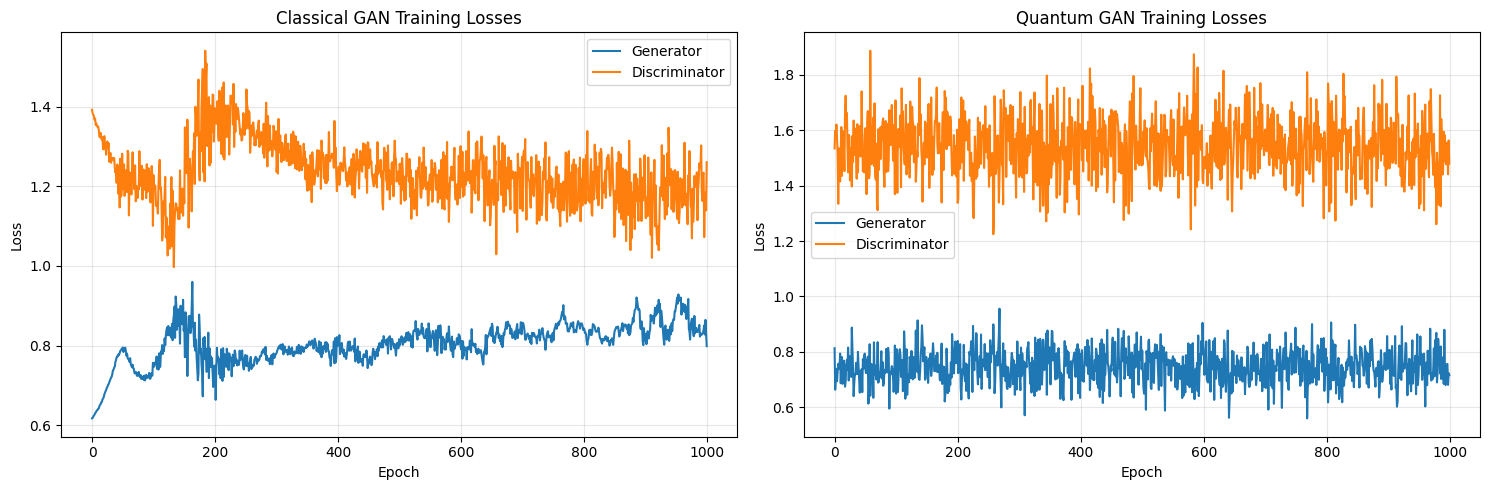

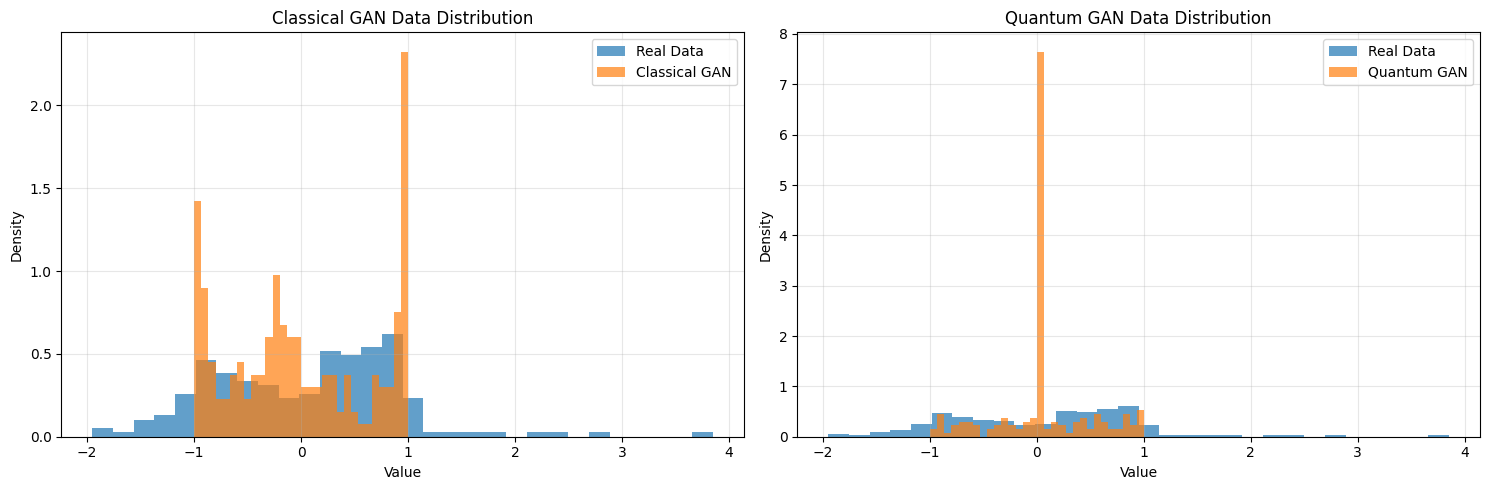

In [193]:
# Plot training losses
plt.figure(figsize=(15, 5))

# Classical GAN losses
plt.subplot(1, 2, 1)
plt.plot(classical_g_losses, label='Generator')
plt.plot(classical_d_losses, label='Discriminator')
plt.title('Classical GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Quantum GAN losses
plt.subplot(1, 2, 2)
plt.plot(qgan.generator_losses, label='Generator')
plt.plot(qgan.discriminator_losses, label='Discriminator')
plt.title('Quantum GAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot data distributions
plt.figure(figsize=(15, 5))

# Classical GAN distributions
plt.subplot(1, 2, 1)
plt.hist(real_data[:num_test_samples].flatten(), bins=30, alpha=0.7, label='Real Data', density=True)
plt.hist(classical_samples.flatten(), bins=30, alpha=0.7, label='Classical GAN', density=True)
plt.title('Classical GAN Data Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Quantum GAN distributions
plt.subplot(1, 2, 2)
plt.hist(real_data[:num_test_samples].flatten(), bins=30, alpha=0.7, label='Real Data', density=True)
plt.hist(quantum_samples.flatten(), bins=30, alpha=0.7, label='Quantum GAN', density=True)
plt.title('Quantum GAN Data Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

In this notebook, we implemented and compared Classical and Quantum GANs. Key observations:

1. Training Stability: The classical GAN shows more stable training curves, while the quantum GAN exhibits more fluctuations due to quantum noise and measurement uncertainties.

2. Data Distribution: Both models attempt to learn the underlying data distribution, but with different characteristics:
   - Classical GAN tends to produce smoother distributions
   - Quantum GAN shows more discrete, quantum-like features

3. Performance Metrics: The Wasserstein distance and KL divergence metrics provide quantitative comparison between the approaches.

4. Resource Requirements: 
   - Classical GAN: More parameter-efficient but requires gradient computations
   - Quantum GAN: Fewer parameters but requires quantum circuit simulations

The choice between classical and quantum approaches depends on the specific application requirements and available quantum resources.

# Classical vs Quantum GAN Comparison - Enhanced Analysis

This notebook extends the Classical and Quantum GAN comparison with enhanced analysis, including per-dimension Wasserstein distances, 2D KDE plots, and MMD comparisons. Checkpointing and best model evaluation are also demonstrated.

Per-dimension Wasserstein distances (classical): [0.09029104 0.30426732]
Per-dimension Wasserstein distances (quantum): [0.08660365 0.81413822]


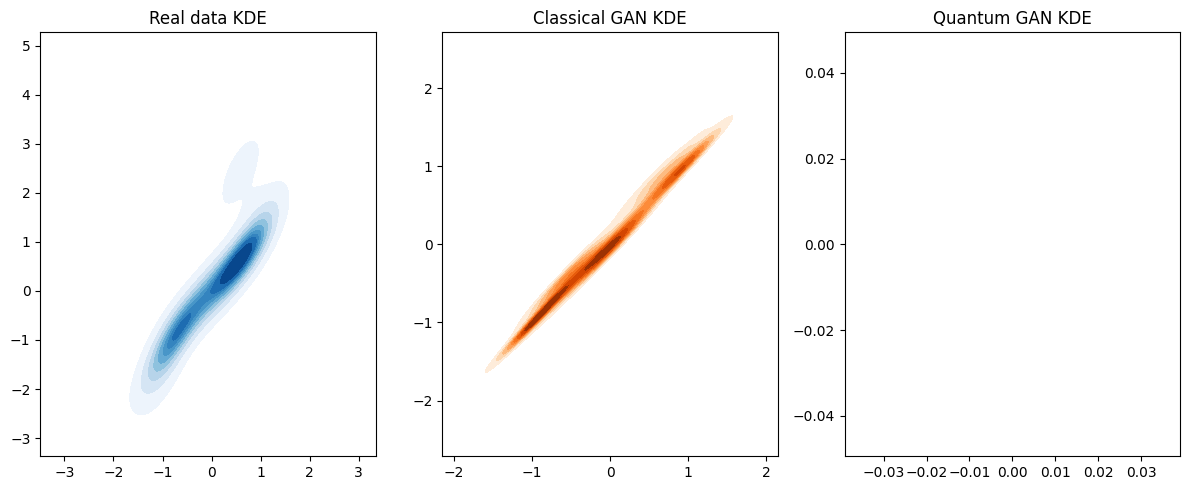

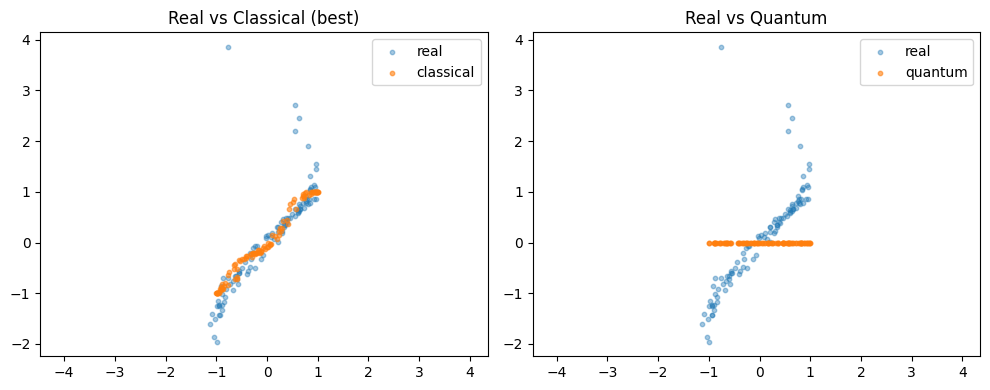

Final MMD (classical, best): 0.032260
Final MMD (quantum): 0.279796
Best model by MMD: classical
Saved comparison summary to comparison_summary.json


In [194]:
# Enhanced Visualization & Analysis: Wasserstein per-dimension, 2D KDE, contingency that best model is tested

# Ensure classical_samples comes from the best saved generator
if 'classical_samples' not in globals():
    with torch.no_grad():
        z = torch.randn(100, classical_config.latent_dim).to(device)
        classical_samples = classical_generator(z).cpu().numpy()

# Quantum samples (already generated earlier in the notebook; if not, generate now)
if 'quantum_samples' not in globals():
    try:
        quantum_samples = qgan.generate_samples(num_test_samples)
    except Exception:
        quantum_samples = np.array(qgan.generate_samples(num_test_samples))

# Per-dimension Wasserstein distances
def per_dimension_wasserstein(real, gen):
    real = np.asarray(real)
    gen = np.asarray(gen)
    dists = []
    for i in range(real.shape[1]):
        d = wasserstein_distance(real[:, i], gen[:, i])
        dists.append(d)
    return np.array(dists)

# Use a common reference real subset
ref_real = real_data[:100]

w_classical = per_dimension_wasserstein(ref_real, classical_samples)
w_quantum = per_dimension_wasserstein(ref_real, quantum_samples)

print('Per-dimension Wasserstein distances (classical):', w_classical)
print('Per-dimension Wasserstein distances (quantum):', w_quantum)

# KDE / density plots (2D)
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.kdeplot(x=ref_real[:,0], y=ref_real[:,1], cmap='Blues', fill=True, thresh=0.05)
plt.title('Real data KDE')
plt.axis('equal')

plt.subplot(1,3,2)
sns.kdeplot(x=classical_samples[:,0], y=classical_samples[:,1], cmap='Oranges', fill=True, thresh=0.05)
plt.title('Classical GAN KDE')
plt.axis('equal')

plt.subplot(1,3,3)
sns.kdeplot(x=quantum_samples[:,0], y=quantum_samples[:,1], cmap='Greens', fill=True, thresh=0.05)
plt.title('Quantum GAN KDE')
plt.axis('equal')

plt.tight_layout()
plt.show()

# 2D scatter overlays with contour
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(ref_real[:,0], ref_real[:,1], s=10, alpha=0.4, label='real')
plt.scatter(classical_samples[:,0], classical_samples[:,1], s=10, alpha=0.6, label='classical')
plt.title('Real vs Classical (best)')
plt.legend()
plt.axis('equal')

plt.subplot(1,2,2)
plt.scatter(ref_real[:,0], ref_real[:,1], s=10, alpha=0.4, label='real')
plt.scatter(quantum_samples[:,0], quantum_samples[:,1], s=10, alpha=0.6, label='quantum')
plt.title('Real vs Quantum')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# Compute MMD on a larger set for final comparison
N_eval = 1000
# Choose available data pool for evaluation (fallbacks if `dataset` is not present)
if 'dataset' in globals():
    # support both an object with .data or a plain array
    pool = getattr(dataset, 'data', None) or dataset
elif 'real_data' in globals():
    pool = real_data
elif 'train_data' in globals():
    pool = train_data
else:
    raise NameError("No available data pool found for evaluation. Define 'dataset' or 'real_data' or 'train_data'.")

idxs = np.random.choice(len(pool), N_eval, replace=False)
ref_eval = pool[idxs]

# If generators can produce N_eval samples
with torch.no_grad():
    z = torch.randn(N_eval, classical_config.latent_dim).to(device)
    classical_eval = best_classical_generator(z).cpu().numpy()
try:
    quantum_eval = qgan.generate_samples(N_eval)
except Exception:
    quantum_eval = np.array(qgan.generate_samples(N_eval))

mmd_classical_final = compute_mmd(ref_eval, classical_eval, sigma=0.5)
mmd_quantum_final = compute_mmd(ref_eval, quantum_eval, sigma=0.5)

print(f'Final MMD (classical, best): {mmd_classical_final:.6f}')
print(f'Final MMD (quantum): {mmd_quantum_final:.6f}')

# Decide which model is best by MMD
best_by_mmd = 'classical' if mmd_classical_final < mmd_quantum_final else 'quantum'
print('Best model by MMD:', best_by_mmd)

# Save comparison summary
summary = {
    'mmd_classical_final': float(mmd_classical_final),
    'mmd_quantum_final': float(mmd_quantum_final),
    'per_dim_wasserstein_classical': w_classical.tolist(),
    'per_dim_wasserstein_quantum': w_quantum.tolist(),
    'best_by_mmd': best_by_mmd,
}
with open('comparison_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved comparison summary to comparison_summary.json')

In [195]:
print("real_data.shape:", np.asarray(real_data).shape)
print("classical_samples.shape:", np.asarray(classical_samples).shape)
print("quantum_samples.shape:", np.asarray(quantum_samples).shape)

def stats(name, arr):
    arr = np.asarray(arr)
    print(name, "mean:", arr.mean(axis=0), "std:", arr.std(axis=0), "min:", arr.min(axis=0), "max:", arr.max(axis=0))
stats("real_data", real_data)
stats("classical", classical_samples)
stats("quantum", quantum_samples)

real_data.shape: (1000, 2)
classical_samples.shape: (100, 2)
quantum_samples.shape: (100, 2)
real_data mean: [0.02621709 0.05807652] std: [0.6656739  1.01550022] min: [-1.14055666 -2.94038863] max: [1.25074936 3.85273149]
classical mean: [-0.02498841  0.02139077] std: [0.6635156 0.6967215] min: [-0.9982576 -0.9998951] max: [0.9999038 1.       ]
quantum mean: [0.07174603 0.        ] std: [0.59950631 0.        ] min: [-1.  0.] max: [1. 0.]


In [196]:
print("var real:", np.var(real_data, axis=0))
print("var classical:", np.var(classical_samples, axis=0))
print("var quantum:", np.var(quantum_samples, axis=0))

# check if any column is almost constant
for name, arr in [("real", real_data), ("classical", classical_samples), ("quantum", quantum_samples)]:
    arr = np.asarray(arr)
    for i in range(arr.shape[1]):
        print(name, "dim", i, "unique_count:", np.unique(np.round(arr[:,i],6)).shape[0])

var real: [0.44312175 1.03124069]
var classical: [0.44025302 0.48542082]
var quantum: [0.35940781 0.        ]
real dim 0 unique_count: 1000
real dim 1 unique_count: 1000
classical dim 0 unique_count: 100
classical dim 1 unique_count: 100
quantum dim 0 unique_count: 47
quantum dim 1 unique_count: 1


IndexError: index 2 is out of bounds for axis 1 with size 2

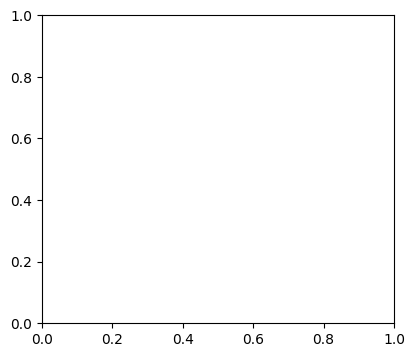

In [197]:
# color points by the 3rd coordinate
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(real_data[:,0], real_data[:,1], c=real_data[:,2], cmap='viridis', s=20)
plt.title('Real (color=dim2)')
plt.subplot(1,2,2)
plt.scatter(classical_samples[:,0], classical_samples[:,1], c=classical_samples[:,2] if classical_samples.shape[1]>2 else np.zeros(len(classical_samples)), cmap='viridis', s=20)
plt.title('Classical (color=dim2)')
plt.colorbar()
plt.show()

# If 3D plotting is available:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(real_data[:,0], real_data[:,1], real_data[:,2], s=6, alpha=0.6)
ax.set_title('Real 3D')
plt.show()